In [1]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

This notebook is based on code provided by Scikit-learn developers and uses Scikit-learn along with some other libraries.

https://scikit-learn.org/stable/modules/neighbors.html#classification

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import seaborn as sns

### K-Nearest Neighbours classification on the Iris dataset

In this notebook, we will be using K-nearest neighbours to classify the species of flower given measurements of its physical characteristics. The dataset we will use is called the Iris dataset.

The Iris dataset can be found here: https://archive.ics.uci.edu/dataset/53/iris

We can load it using Scikit-learn's utilities. It gives us two tables loaded as Pandas dataframes, `iris.data` which contains the input features and `iris.target` which contains the corresponding class labels. There are N=150 data points in total.

In [3]:
iris = load_iris(as_frame=True)

The data contains 4 features corresponding to different aspects of each flower

In [4]:
iris.data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


The target contains the type of flower (class). There are 3 classes in total labelled 0, 1 and 2

In [5]:
iris.target

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

#### Exploratory Data Analysis

Let's explore the data. First let's look at the features and statistics.

In [6]:
iris.data.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


We should also check if the classes are imbalanced. It turns out each class has an equal proportion of samples.

<Axes: xlabel='target'>

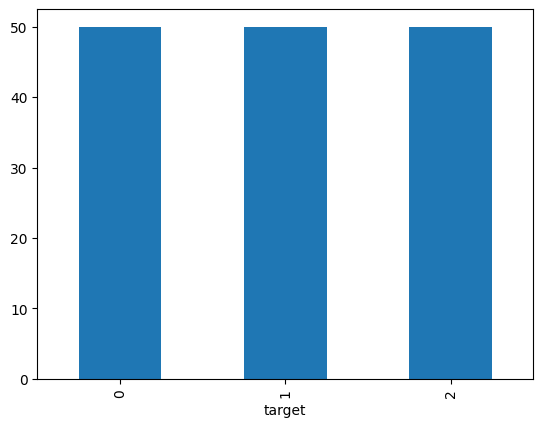

In [7]:
iris.target.value_counts().plot.bar()

Next let's plot the data using `pairplot` from the Seaborn library. This will help us uncover patterns in the data.

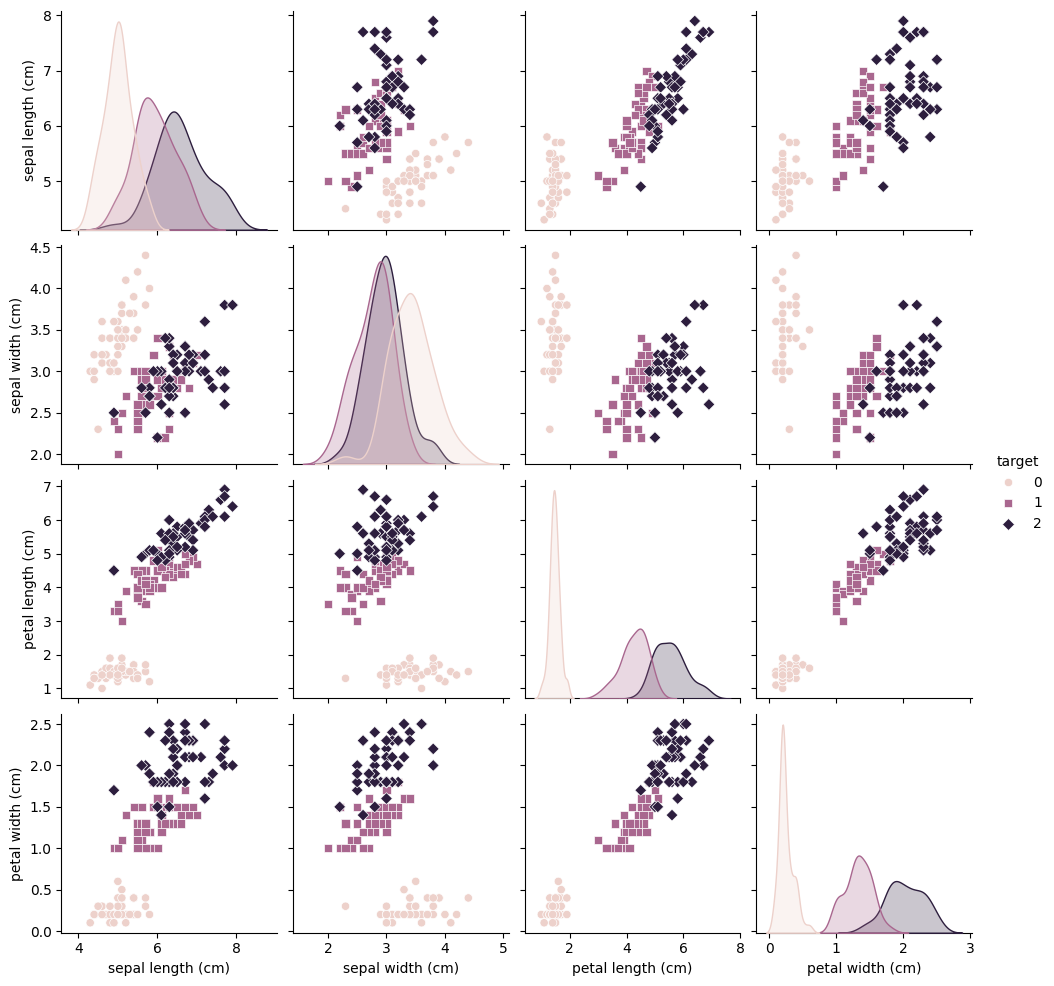

In [8]:
plot_data = pd.concat([iris.data, pd.DataFrame(iris.target)], axis=1)
sns.pairplot(plot_data, hue='target', markers=['o', 's', 'D'])

<!-- It is usually a good idea to normalize the data before training a model. We use sklearn's `StandardScaler` to do this. -->

In [9]:
# data_scaled = StandardScaler().fit_transform(iris.data)
# plot_data = pd.concat([pd.DataFrame(data_scaled, columns=iris.data.columns), pd.DataFrame(iris.target)], axis=1)
# sns.pairplot(plot_data, hue='target', markers=['o', 's', 'D'])

#### Splitting the dataset into training and test sets

Next we split the dataset into training and test sets. The KNN classifier will be "trained" on the training set and evaluated on the test set.

We use `train_test_split` from Scikit-learn to do this. We split it so that 30% of the samples become the test set and the rest are used for training. The option `stratify` ensures that the class label proportions in the dataset are also reflected in the training and test sets. Since `train_test_split` randomly splits the dataset, the `random_state` option ensures that we get the same split every time we run the code below.

In [10]:
X = iris.data[["sepal length (cm)", "sepal width (cm)"]]
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

We can adjust the number of neighbours using the hyper-parameter `k`. `k` is called a hyper-parameter rather than a parameter because parameters are typically tuned when we train our model. However, `k` is not changed for KNN and we pick `k` before training begins and we continue to use it on unseen (test) data.

In [11]:
k = 11

A `Pipeline` in Scikit learn allows us to pass data through a series of transformations and models.

Here we first transform the data using a `StandardScaler` which standardizes the input features (makes the mean of each column 0 and the standard deviation roughly 1). Scaling or normalization can help many training algorithms reach the solution quicker.

After scaling, the scaled data is passed into the `KNeighborsClassifier` model. We use the `k` we picked in an earlier cell and use `weights="uniform"` which means that the `k` closest neighbours of the point whose class label we are predicting are treated equally. Sometimes, we might want to give more importance to neighbours which are closer and setting `weights="distance"` allows us to do this by weighting neighbours by the inverse of their distance from the input (so closer points are given higher weight). Try setting `weights="distance"` instead of `uniform` below to see how the decision boundary changes later on.

In [12]:
clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=k, weights="uniform"))]
)

Next we use the `.fit` method on the pipeline we created before to train the model on the training data set (`X_train, y_train`). Most models in Scikit-learn which are trainable come with a `.fit` method which let you use some algorithm to train the model.

In [13]:
clf.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(n_neighbors=11))])

We can then use the trained model (in this case a pipeline that contains the trained model, as shown in the figure above) to classify unseen data from the test set. We use the code below to plot the decision boundary of the trained model.

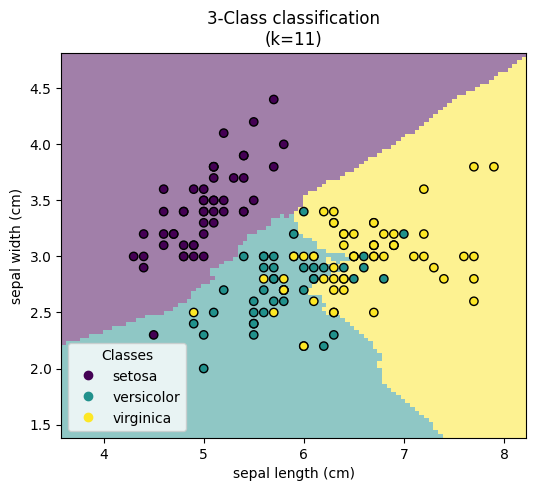

In [14]:
_, ax = plt.subplots(ncols=1, figsize=(6, 5))

disp = DecisionBoundaryDisplay.from_estimator(
    clf,
    X_test,
    response_method="predict",
    plot_method="pcolormesh",
    xlabel=iris.feature_names[0],
    ylabel=iris.feature_names[1],
    shading="auto",
    alpha=0.5,
    ax=ax,
)
scatter = disp.ax_.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolors="k")
disp.ax_.legend(
    scatter.legend_elements()[0],
    iris.target_names,
    loc="lower left",
    title="Classes",
)
_ = disp.ax_.set_title(
    f"3-Class classification\n(k={clf[-1].n_neighbors})"
)

plt.show()

Some of the test points are misclassified. The colors of each region represent the class prediction for points in each region. Some test points however (circles) have a different color (true label) than what is predicted. These points are said to be misclassified. Ideally we want our model to have a minimum number of misclassifications. Let's see if different values of `k` yield different results. Below is a plot of the predictions using values of `k` from 1 to 12

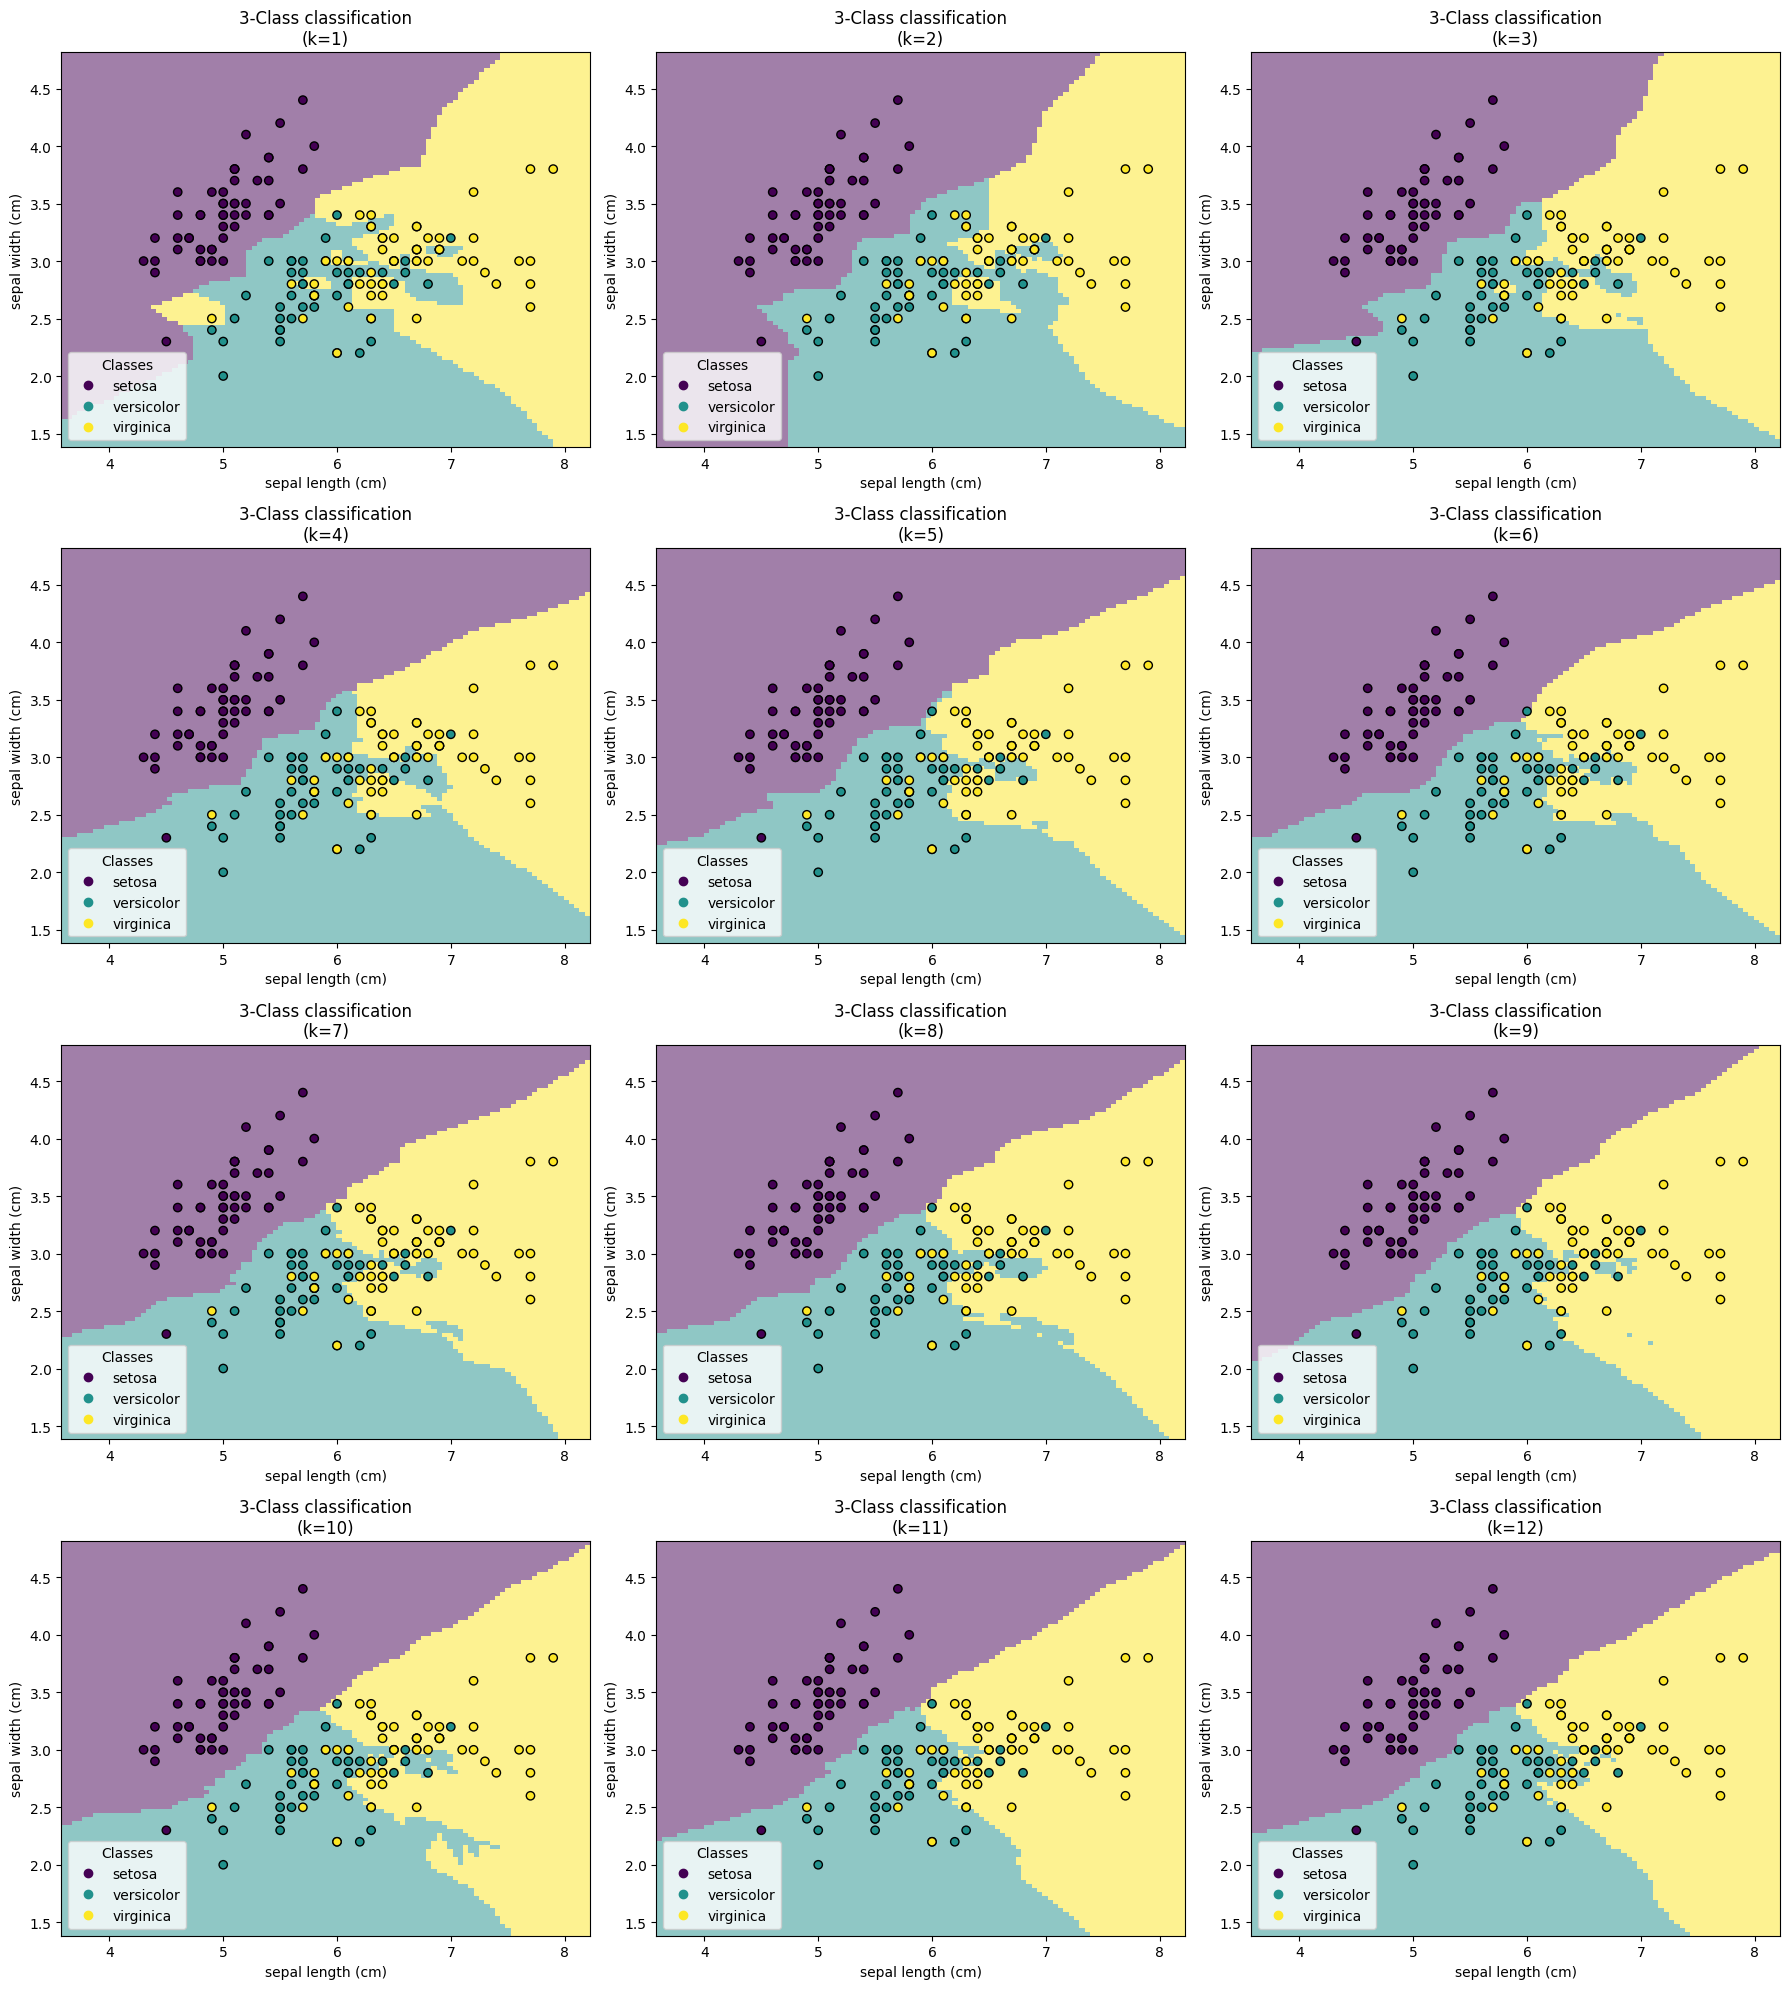

In [15]:
_, axs = plt.subplots(nrows=4, ncols=3, figsize=(18, 20))

train_accuracies = []
test_accuracies = []

for ax, k in zip(axs.flatten(), tuple(range(1, 13))):
    clf.set_params(knn__n_neighbors=k).fit(X_train, y_train)
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X_test,
        response_method="predict",
        plot_method="pcolormesh",
        xlabel=iris.feature_names[0],
        ylabel=iris.feature_names[1],
        shading="auto",
        alpha=0.5,
        ax=ax,
    )
    scatter = disp.ax_.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolors="k")
    disp.ax_.legend(
        scatter.legend_elements()[0],
        iris.target_names,
        loc="lower left",
        title="Classes",
    )
    _ = disp.ax_.set_title(
        f"3-Class classification\n(k={clf[-1].n_neighbors})"
    )

    train_accuracy = accuracy_score(y_train, clf.predict(X_train))
    train_accuracies.append(train_accuracy)

    test_accuracy = accuracy_score(y_test, clf.predict(X_test))
    test_accuracies.append(test_accuracy)

plt.tight_layout()
plt.show()

Each of them gives a slightly different decision boundary since each considers a different number of neighbours for prediction. (See how the boundaries change by setting `weights="distance"` in the pipeline and re-running the code).

Looking at the plots it seems like they all perform somewhat similarly. But we can compare the different models by computing their accuracy on the test set. The accuracy is the ratio of correctly classified points (and would be 1.0 for a model that performs perfectly). Below is a plot of the accuracy of each of the above models on the training as well as test set. Usually we would expect the model to perform slightly better on the training set.

Text(0.5, 1.0, 'Plot of how the models accuracy changes as a function of k')

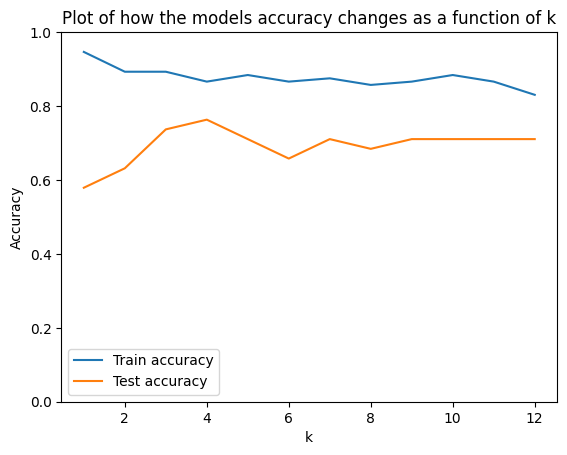

In [16]:
plt.plot(range(1, 13), train_accuracies, label='Train accuracy')
plt.plot(range(1, 13), test_accuracies, label='Test accuracy')
plt.ylim((0, 1))
plt.legend()
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Plot of how the models accuracy changes as a function of k')

Instead of spliting into just a training and test set, we could split the data into three parts: the training, validation and test set. Typically, we would then train the model on the training set and compute the accuracy of the model for different values of `k` on the validation set. This would allow us to choose the best model (best value of `k`). This is sometimes known as hyper-parameter tuning or hyper-parameter selection. Then selected model would be evaluated on the test set to measure how well it generalizes. If the model (in this case the value of `k`) picked using the performance on the validation set performs poorly on the test set, we might want to use a different method / model for the dataset that we have.